<a href="https://colab.research.google.com/github/AbnerJSV/THE_CORE_Trabajos_iA/blob/main/cifar_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU disponible: []


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)

class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Hiperparámetros
IMG_SIZE = 96
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)


In [ ]:
def resize_and_preprocess(images, labels):
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    images = preprocess_input(images)   # Escala específica de EfficientNet (diferente de MobileNet)
    labels = tf.one_hot(labels, depth=10)
    labels = tf.reshape(labels, (-1, 10))
    return images, labels

# División train/val 80/20
full_train = tf.data.Dataset.from_tensor_slices((x_train, y_train))
full_train = full_train.shuffle(50000, seed=42)

train_size = int(0.8 * len(x_train))
train_ds = full_train.take(train_size)
val_ds = full_train.skip(train_size)

# Aplicar batching, map y prefetch
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Verificación
for img, lbl in train_ds.take(1):
    print("Rango de imágenes (debe ser algo como -1 a 1):", img.numpy().min(), img.numpy().max())
    print("Forma etiquetas:", lbl.numpy().shape)

Rango de imágenes (debe ser algo como -1 a 1): 0.0 255.0
Forma etiquetas: (64, 10)


In [ ]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Data augmentation potente
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
])

# Cabezal clasificador
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,101 (16.71 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [ ]:
callbacks_fase1 = [
    keras.callbacks.ModelCheckpoint(
        "modelo_fase1.keras",          # formato .keras evita warnings
        save_best_only=True,
        monitor='val_accuracy'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

print(" Fase 1: Entrenando cabeza...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                     # Suficientes, early stopping parará antes
    steps_per_epoch=500,
    validation_steps=100,
    callbacks=callbacks_fase1
)

# Evaluación rápida después de fase 1
test_loss, test_acc = model.evaluate(test_ds, steps=200)
print(f" Accuracy tras fase 1 (sobre test): {test_acc:.4f}")

🚀 Fase 1: Entrenando cabeza...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 514s 1s/step - accuracy: 0.6887 - loss: 0.9773 - val_accuracy: 0.8478 - val_loss: 0.4528 - learning_rate: 0.0010
Epoch 2/20
125/500 ━━━━━━━━━━━━━━━━━━━━ 4:58 797ms/step - accuracy: 0.7252 - loss: 0.8012

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 329ms/step - accuracy: 0.7325 - loss: 0.7760 - val_accuracy: 0.8470 - val_loss: 0.4490 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 478s 927ms/step - accuracy: 0.7602 - loss: 0.7059 - val_accuracy: 0.8566 - val_loss: 0.4344 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 403ms/step - accuracy: 0.7571 - loss: 0.6932 - val_accuracy: 0.8544 - val_loss: 0.4258 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 506s 978ms/step - accuracy: 0.7719 - loss: 0.6649 - val_accuracy: 0.8692 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 335ms/step - accuracy: 0.7793 - loss: 0.6616 - val_accuracy: 0.8617 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 453s 906ms/step - accuracy: 0.7797 - loss: 0.6396 - val_accuracy: 0.8708 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 320ms/step - accuracy: 0.7857 

In [ ]:
# Descongelar solo las últimas 30 capas de EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Verificar cuántas capas quedan entrenables
trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Capas entrenables en fine-tuning: {len(trainable_layers)}")

# Recompilar con learning rate MUY bajo
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    keras.callbacks.ModelCheckpoint(
        "modelo_finetune.keras",
        save_best_only=True,
        monitor='val_accuracy'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),
]

print("🔥 Fase 2: Fine-tuning...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    steps_per_epoch=500,
    validation_steps=100,
    callbacks=callbacks_fase2
)

Capas entrenables en fine-tuning: 30
🔥 Fase 2: Fine-tuning...
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.7225 - loss: 0.8081 - val_accuracy: 0.8350 - val_loss: 0.4886
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 193s 386ms/step - accuracy: 0.7444 - loss: 0.7512 - val_accuracy: 0.8303 - val_loss: 0.4972
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 603s 1s/step - accuracy: 0.7547 - loss: 0.7178 - val_accuracy: 0.8545 - val_loss: 0.4352
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 194s 386ms/step - accuracy: 0.7649 - loss: 0.6862 - val_accuracy: 0.8609 - val_loss: 0.4267
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.7710 - loss: 0.6758 - val_accuracy: 0.8572 - val_loss: 0.4200
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 191s 380ms/step - accuracy: 0.7750 - loss: 0.6490 - val_accuracy: 0.8622 - val_loss: 0.4157
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.7804 - loss: 0.6441 - val_accuracy: 0.8661 - val_loss: 0.3953
Epoch 8/15
500/500 ━━━━━━━

In [7]:
# Cargar el mejor modelo de fine-tuning
best_model = keras.models.load_model("modelo_finetune.keras")

# Evaluar en todo el test set
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\n🎯 PRECISIÓN FINAL EN TEST: {test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 114s 682ms/step - accuracy: 0.8648 - loss: 0.4051

🎯 PRECISIÓN FINAL EN TEST: 0.8648


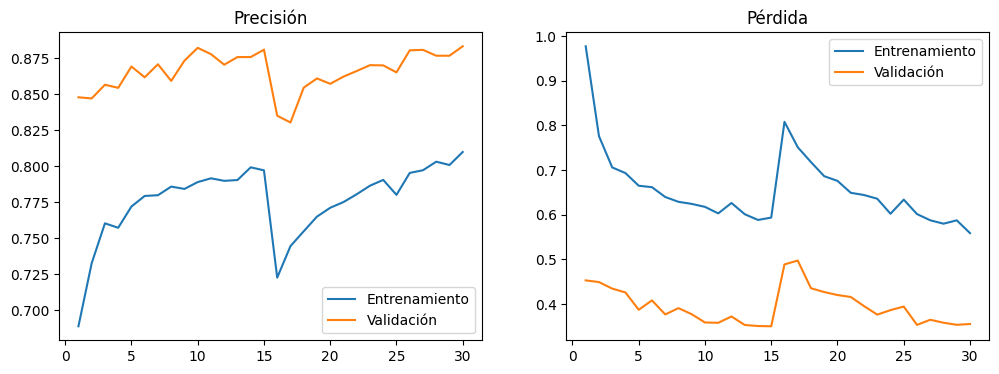

In [8]:
# Concatenar historiales (si ambos existen)
if 'history1' in dir() and 'history2' in dir():
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Entrenamiento')
    plt.plot(epochs_range, val_acc, label='Validación')
    plt.legend()
    plt.title('Precisión')
    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Entrenamiento')
    plt.plot(epochs_range, val_loss, label='Validación')
    plt.legend()
    plt.title('Pérdida')
    plt.show()
else:
    print("No hay history2, solo se muestra history1")
    # (opcional) graficar solo history1